# AlphaLens Event-Driven Strategy Backtest

This notebook converts the locked XGBoost test predictions into executable daily positions. Signals start at the feature-session close, expire at the 30-session target date, and never use realized labels for portfolio construction. Results include gross performance, 10 bps one-way transaction costs, turnover, drawdown, and SPY buy-and-hold.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from pipelines.ml.backtest import run_event_backtest
from pipelines.ml.dataset import get_database_engine, load_adjusted_prices
from pipelines.ml.features import build_event_feature_dataset
from pipelines.ml.xgboost_model import run_xgboost_experiment

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 30)

## Build the locked test portfolio

Portfolio rules are fixed at top three, bottom three, at least four active company signals, and 10 bps per unit of traded notional.

In [2]:
engine = get_database_engine()
dataset = build_event_feature_dataset(engine, horizon=30)
experiment = run_xgboost_experiment(dataset)
model_name = next(name for name in experiment.test_predictions['model'].unique() if name.startswith('xgboost_selected_'))
predictions = experiment.test_predictions.loc[experiment.test_predictions['model'] == model_name]
backtest = run_event_backtest(
    predictions,
    load_adjusted_prices(engine),
    top_k=3,
    min_signals=4,
    transaction_cost_bps=10,
)
display(backtest.summary)

,strategy,trading_days,total_return,annualized_return,annualized_volatility,sharpe,max_drawdown,positive_day_rate,average_daily_turnover,total_turnover
0,xgboost_long_short_gross,254,-0.007268,-0.007211,0.113346,-0.007214,-0.106773,0.409449,0.180446,45.833333
1,xgboost_long_short_net,254,-0.051778,-0.051381,0.113628,-0.407381,-0.119403,0.405512,0.180446,45.833333
2,xgboost_long_only_gross,254,0.031019,0.030771,0.201190,0.251225,-0.191724,0.413386,0.198163,50.333333
3,xgboost_long_only_net,254,-0.019682,-0.019528,0.201628,0.003010,-0.204107,0.401575,0.198163,50.333333
4,spy_buy_and_hold,254,0.212027,0.210193,0.125769,1.580403,-0.088850,0.547244,NaN,NaN


## Gross, net, and benchmark wealth

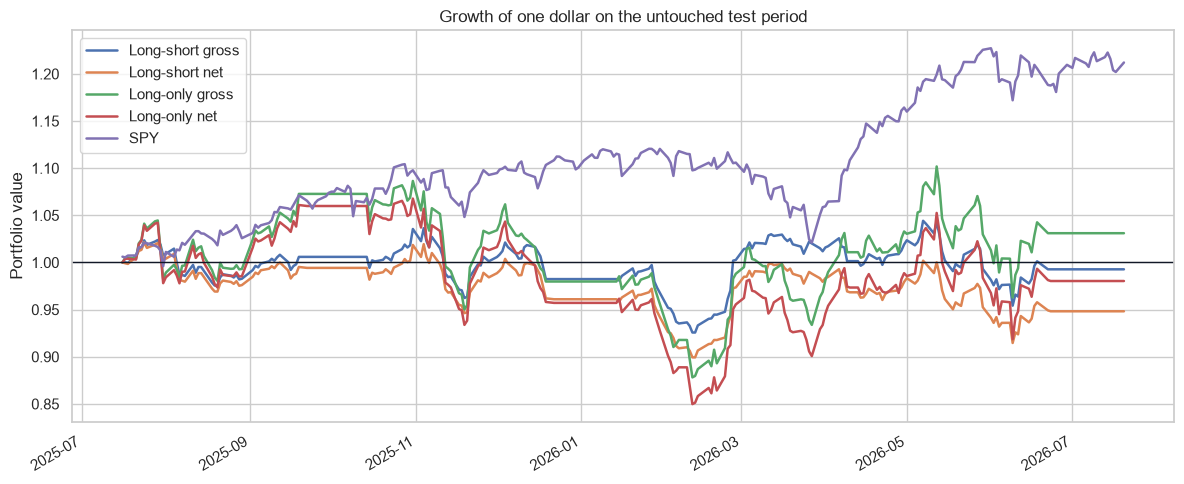

In [3]:
daily = backtest.daily_returns.set_index('trading_date').copy()
wealth = pd.DataFrame({
    'Long-short gross': (1 + daily['long_short_gross_return']).cumprod(),
    'Long-short net': (1 + daily['long_short_net_return']).cumprod(),
    'Long-only gross': (1 + daily['long_only_gross_return']).cumprod(),
    'Long-only net': (1 + daily['long_only_net_return']).cumprod(),
    'SPY': (1 + daily['spy_return']).cumprod(),
})
fig, ax = plt.subplots(figsize=(12, 5))
wealth.plot(ax=ax, linewidth=1.8)
ax.axhline(1, color='#111827', linewidth=1)
ax.set(title='Growth of one dollar on the untouched test period', xlabel='', ylabel='Portfolio value')
plt.tight_layout()
plt.show()

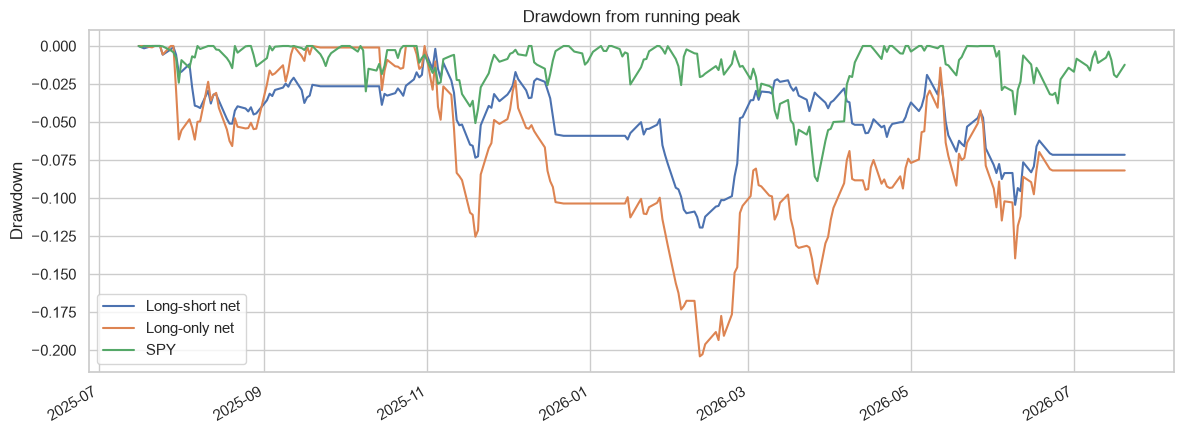

In [4]:
drawdowns = wealth / wealth.cummax() - 1
fig, ax = plt.subplots(figsize=(12, 4.5))
drawdowns[['Long-short net', 'Long-only net', 'SPY']].plot(ax=ax)
ax.set(title='Drawdown from running peak', xlabel='', ylabel='Drawdown')
plt.tight_layout()
plt.show()

## Signal breadth and trading friction

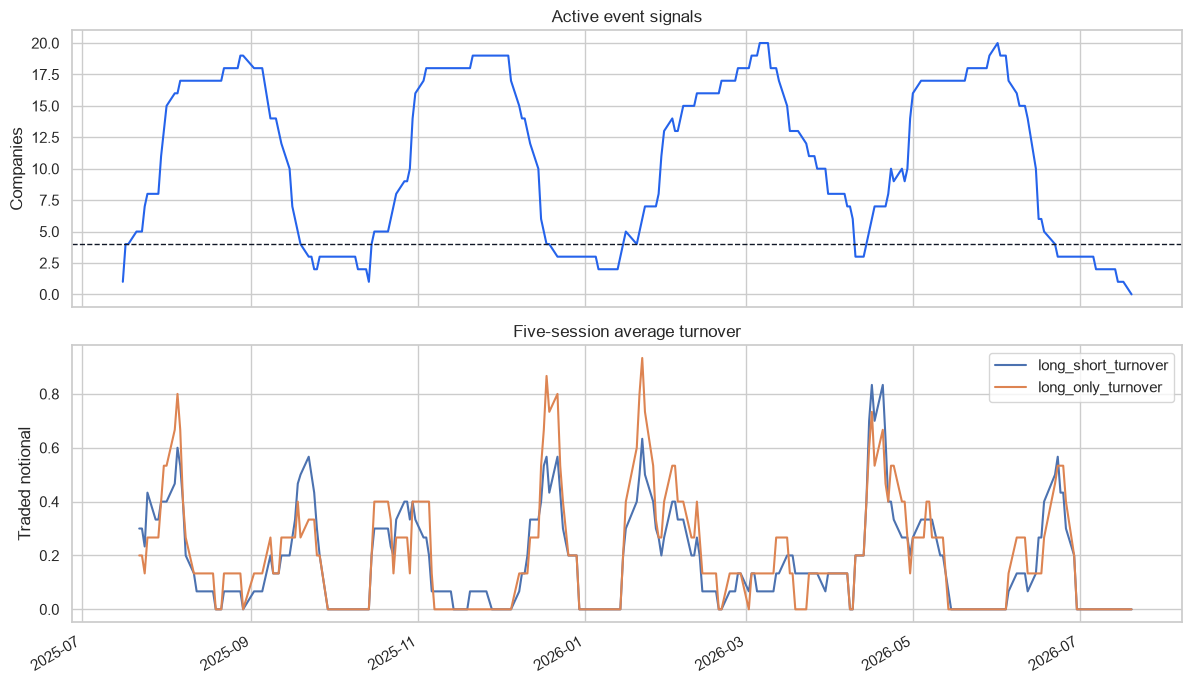

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
daily['active_signals'].plot(ax=axes[0], color='#2563eb')
axes[0].axhline(4, color='#111827', linestyle='--', linewidth=1)
axes[0].set(title='Active event signals', ylabel='Companies')
daily[['long_short_turnover', 'long_only_turnover']].rolling(5).mean().plot(ax=axes[1])
axes[1].set(title='Five-session average turnover', xlabel='', ylabel='Traded notional')
plt.tight_layout()
plt.show()

In [6]:
position_audit = pd.Series({
    'test_days': len(daily),
    'invested_days': int((daily['long_positions'] > 0).sum()),
    'unique_events_traded': backtest.weights['event_key'].nunique(),
    'unique_tickers_traded': backtest.weights['ticker'].nunique(),
    'average_active_signals': daily['active_signals'].mean(),
})
display(position_audit)
display(backtest.weights.tail(20))

test_days                 254.000000
invested_days             199.000000
unique_events_traded      104.000000
unique_tickers_traded      20.000000
average_active_signals     10.956693
dtype: float64

,trading_date,ticker,event_key,feature_as_of_date,target_trading_date,prediction,position,long_short_weight,long_only_weight
1128,2026-06-16,CAT,sec_filing:0000018230-26-000021,2026-05-07,2026-06-22,0.008638,long,0.166667,0.333333
1129,2026-06-16,COST,sec_filing:0000909832-26-000051,2026-06-04,2026-07-20,0.003980,short,-0.166667,0.000000
1130,2026-06-16,CVX,sec_filing:0000093410-26-000113,2026-05-08,2026-06-23,-0.011181,short,-0.166667,0.000000
1131,2026-06-16,NVDA,sec_filing:0001045810-26-000052,2026-05-21,2026-07-07,0.008120,long,0.166667,0.333333
1132,2026-06-16,UNH,sec_filing:0000731766-26-000127,2026-05-06,2026-06-18,-0.001715,short,-0.166667,0.000000
1133,2026-06-16,WMT,sec_filing:0000104169-26-000102,2026-06-01,2026-07-15,0.007467,long,0.166667,0.333333
1134,2026-06-17,CAT,sec_filing:0000018230-26-000021,2026-05-07,2026-06-22,0.008638,long,0.166667,0.333333
1135,2026-06-17,COST,sec_filing:0000909832-26-000051,2026-06-04,2026-07-20,0.003980,short,-0.166667,0.000000
1136,2026-06-17,CVX,sec_filing:0000093410-26-000113,2026-05-08,2026-06-23,-0.011181,short,-0.166667,0.000000
1137,2026-06-17,NVDA,sec_filing:0001045810-26-000052,2026-05-21,2026-07-07,0.008120,long,0.166667,0.333333


## Interpretation

A backtest is an evaluation, not a promise of alpha. Gross-versus-net performance separates model quality from implementation friction. Poor untouched-test results remain part of the experiment record and must not be used to repeatedly redesign the model or portfolio until the test set looks favorable.